<a href="https://colab.research.google.com/github/Shilpa2190/Aerial_Object_Classification/blob/main/Aerial_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = r"/content/drive/MyDrive/Aerial_Classification"
train_dir = r"/content/drive/MyDrive/Aerial_Classification/classification_dataset/train"
test_dir =  r"/content/drive/MyDrive/Aerial_Classification/classification_dataset/test"
valid_dir = r"/content/drive/MyDrive/Aerial_Classification/classification_dataset/valid"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
# Training data generator with augmentation

train_datagen = ImageDataGenerator(
  rescale=1./255, # Normalize pixel values to [0,1]

 # Data augmentation Parameters
 rotation_range=20,
 width_shift_range=0.2,
 height_shift_range=0.2,
 zoom_range=0.2,
 horizontal_flip=True,
 vertical_flip=False,
 fill_mode='nearest'
)

# Validation and test generators (only rescaling, no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Set image size nd baatch size
img_width, img_height = 224, 224  # Adjust as it needed
batch_size = 32

# Create data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size = batch_size,
    class_mode='categorical'     # or 'binary' if you have two classes
)

validation_generator = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 2675 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [ ]:
# Get the classnames and number of classes

test_generator.class_indices

{'bird': 0, 'drone': 1}

In [ ]:
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Class names: ['bird', 'drone']
Number of classes: 2


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Building a Custom Model

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs = epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 722s 9s/step - accuracy: 0.5974 - loss: 0.7694 - precision: 0.5974 - recall: 0.5974 - val_accuracy: 0.6178 - val_loss: 0.6602 - val_precision: 0.6178 - val_recall: 0.6178
Epoch 2/10
 1/83 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.5938 - loss: 0.6995 - precision: 0.5938 - recall: 0.5938

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.5938 - loss: 0.6995 - precision: 0.5938 - recall: 0.5938 - val_accuracy: 0.5865 - val_loss: 0.6667 - val_precision: 0.5865 - val_recall: 0.5865
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 44s 529ms/step - accuracy: 0.6901 - loss: 0.5834 - precision: 0.6901 - recall: 0.6901 - val_accuracy: 0.7284 - val_loss: 0.5415 - val_precision: 0.7284 - val_recall: 0.7284
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7188 - loss: 0.5397 - precision: 0.7188 - recall: 0.7188 - val_accuracy: 0.7284 - val_loss: 0.5376 - val_precision: 0.7284 - val_recall: 0.7284
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 45s 538ms/step - accuracy: 0.7196 - loss: 0.5507 - precision: 0.7196 - recall: 0.7196 - val_accuracy: 0.7404 - val_loss: 0.5064 - val_precision: 0.7404 - val_recall: 0.7404
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6562 - loss: 0.6560 - precision: 0.6562 - recall: 0.6562 - val_accuracy: 0.7476 - val_loss: 0.5107 - val

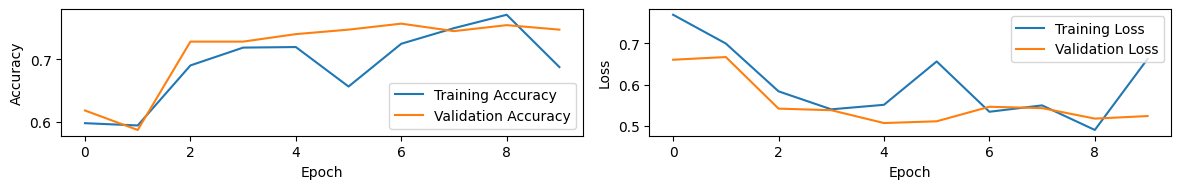

In [ ]:
def plot_history(history):
  plt.figure(figsize=(12,2))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'],label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()
plot_history(history)

In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f'\nTest Accuracy:{test_accuracy:.4f}')
print(f'Test Precision : {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 58s 10s/step - accuracy: 0.8093 - loss: 0.4224 - precision: 0.8093 - recall: 0.8093

Test Accuracy:0.8093
Test Precision : 0.8093
Test Recall: 0.8093


In [ ]:
test_generator.reset()
predictions = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
predicted_classes = np.argmax(predictions, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step


In [ ]:
true_classes = test_generator.classes

In [ ]:
print('\nClassification Report:')
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Confusion Matrix
conf_mat = confusion_matrix(true_classes, predicted_classes)
print('\nConfusion Matrix:')
print(conf_mat)


Classification Report:
              precision    recall  f1-score   support

        bird       0.86      0.79      0.82       121
       drone       0.76      0.83      0.79        94

    accuracy                           0.81       215
   macro avg       0.81      0.81      0.81       215
weighted avg       0.81      0.81      0.81       215


Confusion Matrix:
[[96 25]
 [16 78]]


In [ ]:
# Using Transfer Learning Models

from tensorflow.keras.applications import (VGG16, ResNet50, MobileNet,
                                          InceptionV3, EfficientNetB0)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

model_comparison = []

In [ ]:
# MobileNet

def evaluate_mobilenet():
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
  base_model.trainable = False

  model = tf.keras.Sequential([
      base_model,
      GlobalAveragePooling2D(),
      Dropout(0.2),
      Dense(num_classes, activation = 'softmax')
  ])

  model.compile(optimizer=Adam(0.001),
                loss = 'categorical_crossentropy',
                metrics = ['accuracy', 'precision', 'recall'])

  history = model.fit(
      train_generator,
      validation_data=validation_generator,
      epochs=10,
      callbacks=[EarlyStopping(patience=3)]
  )

  return model, history

mobilenet_model, mobilenet_history = evaluate_mobilenet()
model_comparison.append({
    'Model': 'MobileNet',
    'Val Accuracy' : max(mobilenet_history.history['val_accuracy']),
    'Val Precision' : max(mobilenet_history.history['val_precision']),
    'Val Recall' : max(mobilenet_history.history['val_recall']),
    'Parameters' : f"{mobilenet_model.count_params():}",
    'Inference Time' : 'Fast',
    'Best For': 'Mobile/Edge devices'
})

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 86s 861ms/step - accuracy: 0.8602 - loss: 0.3200 - precision: 0.8602 - recall: 0.8602 - val_accuracy: 0.9480 - val_loss: 0.1361 - val_precision: 0.9480 - val_recall: 0.9480
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 537ms/step - accuracy: 0.9421 - loss: 0.1332 - precision: 0.9421 - recall: 0.9421 - val_accuracy: 0.9570 - val_loss: 0.0986 - val_precision: 0.9570 - val_recall: 0.9570
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 520ms/step - accuracy: 0.9596 - loss: 0.1076 - precision: 0.9596 - recall: 0.9596 - val_accuracy: 0.9683 - val_loss: 0.0868 - val_precision: 0.9683 - val_recall: 0.9683
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 521ms/step - accuracy: 0.9675 - loss: 0.0859 - precision: 0.9675 - recall: 0.9675 - val_accuracy: 0.9683 - val_loss: 0.0840 - val_precision: 0.9683 - val_recall: 0.9683
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - accuracy: 0.9686 - loss: 0.0846 - precision: 0.968

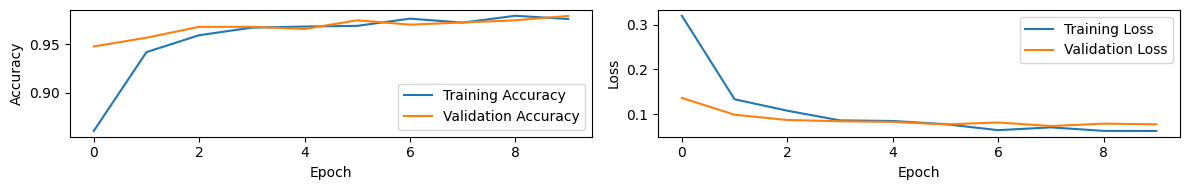

In [ ]:
plot_history(mobilenet_history)

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9814 - loss: 0.0355 - precision: 0.9814 - recall: 0.9814

MobileNet Test accuracy: 0.9814
MobileNet Test Precision: 0.9814
Mobilenet Test Recall: 0.9814
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 718ms/step


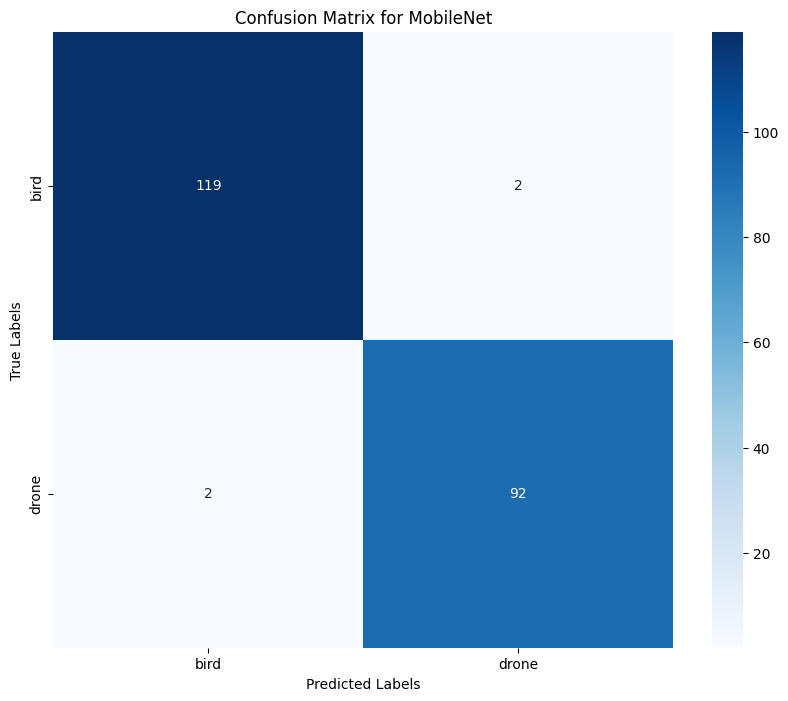

In [ ]:
test_generator.reset()   # Reset the generator before evaluating
test_loss, test_accuracy, test_precision, test_recall = mobilenet_model.evaluate(test_generator)
print(f'\nMobileNet Test accuracy: {test_accuracy:.4f}')
print(f'MobileNet Test Precision: {test_precision:.4f}')
print(f'Mobilenet Test Recall: {test_recall:.4f}')

# Generate predictions for MobileNet
predictions = mobilenet_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


# Get true classes for mobilenet
true_classes = test_generator.classes

# Confusion Matrix for MobileNet
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix for MobileNet using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for MobileNet')
plt.show()

In [ ]:
# ResNet50

def evaluate_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

resnet_model, resnet_history = evaluate_resnet50()
model_comparison.append({
    'Model': 'ResNet50',
    'Val Accuracy': max(resnet_history.history['val_accuracy']),
    'Val Precision': max(resnet_history.history['val_precision']),
    'Val Recall': max(resnet_history.history['val_recall']),
    'Parameters': f"{resnet_model.count_params():,}",
    'Inference Time': 'Medium',
    'Best For': 'General purpose'
})

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 722ms/step - accuracy: 0.5641 - loss: 0.6899 - precision: 0.5641 - recall: 0.5641 - val_accuracy: 0.6403 - val_loss: 0.6294 - val_precision: 0.6403 - val_recall: 0.6403
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 544ms/step - accuracy: 0.6138 - loss: 0.6588 - precision: 0.6138 - recall: 0.6138 - val_accuracy: 0.6041 - val_loss: 0.6353 - val_precision: 0.6041 - val_recall: 0.6041
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 541ms/step - accuracy: 0.6348 - loss: 0.6360 - precision: 0.6348 - recall: 0.6348 - val_accuracy: 0.6448 - val_loss: 0.5991 - val_precision: 0.6448 - val_recall: 0.6448
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 47s 555ms/step - accuracy: 0.6501 - loss: 0.6207 - precision: 0.6501 - recall: 0.6501 - val_accuracy: 0.6290 - val_loss: 0.6031 - val_precision: 0.6290 - val_recall: 0.6290
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 557ms/step - accuracy: 0.6471 - loss: 0.6201 - precision: 0.647

In [ ]:
# VGG16

def evaluate_vgg16():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                  loss= 'categorical_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall')])

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

vgg_model, vgg_history = evaluate_vgg16()
model_comparison.append({
    'Model': 'VGG16',
    'Val Accuracy': max(vgg_history.history['val_accuracy']),
    'Val Precision': max(vgg_history.history['val_precision']),
    'Val Recall' : max(vgg_history.history['val_recall']),
    'Parameters' : f"{vgg_model.count_params():}",
    'Inference Time' : 'Medium',
    'Best For' : 'Medium-sized datasets'
})

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 89s 839ms/step - accuracy: 0.6845 - loss: 0.5951 - precision: 0.6845 - recall: 0.6845 - val_accuracy: 0.8824 - val_loss: 0.4245 - val_precision: 0.8824 - val_recall: 0.8824
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 48s 568ms/step - accuracy: 0.7959 - loss: 0.4545 - precision: 0.7959 - recall: 0.7959 - val_accuracy: 0.8982 - val_loss: 0.3385 - val_precision: 0.8982 - val_recall: 0.8982
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 581ms/step - accuracy: 0.8351 - loss: 0.3990 - precision: 0.8351 - recall: 0.8351 - val_accuracy: 0.9050 - val_loss: 0.2961 - val_precision: 0.9050 - val_recall: 0.9050
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 582ms/step - accuracy: 0.8366 - loss: 0.3739 - precision: 0.8366 - recall: 0.8366 - val_accuracy: 0.9140 - val_loss: 0.2688 - val_precision: 0.9140 - val_recall: 0.9140
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 591ms/step - accuracy: 0.8419 - loss: 0.3465 - precision: 0.841

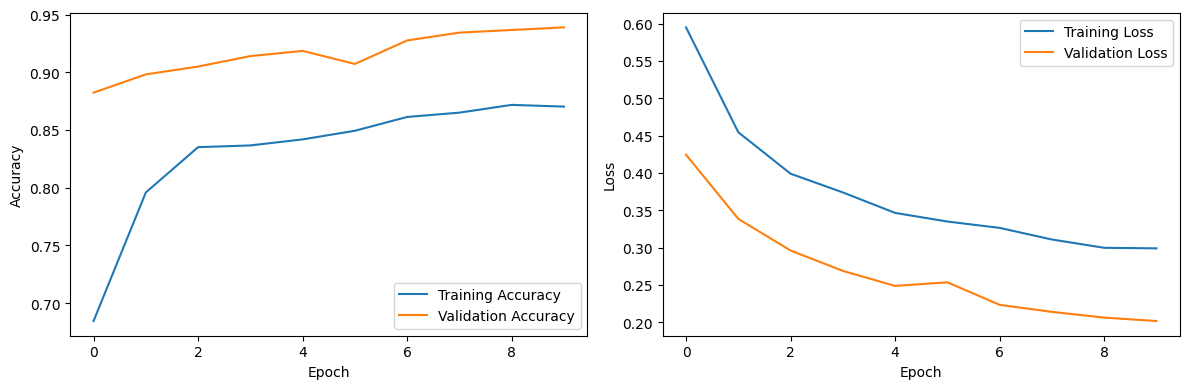

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9070 - loss: 0.2366 - precision: 0.9070 - recall: 0.9070

Test accuracy:0.9070
Test Precision:0.9070
Test Recall : 0.9070


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step


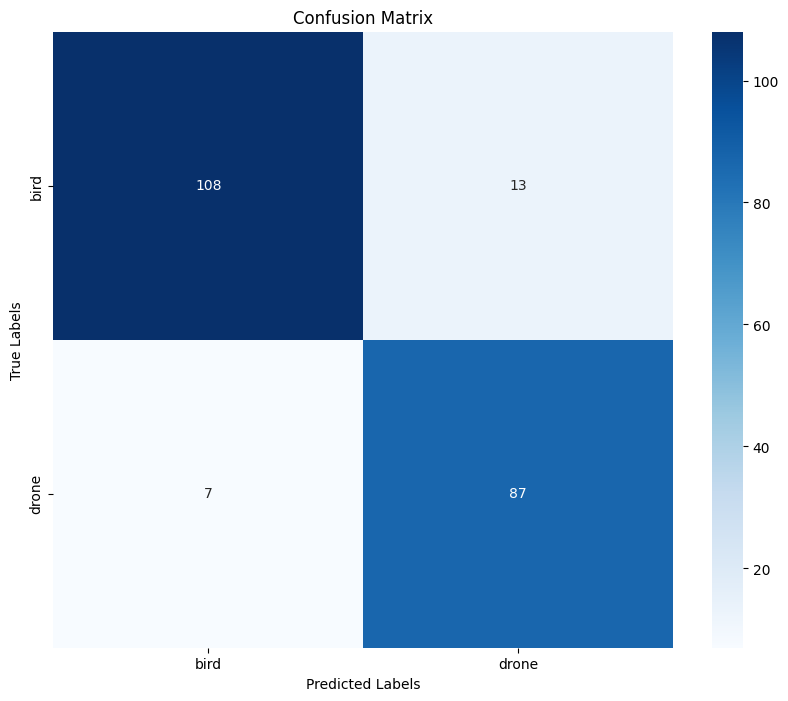

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_history(history):
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label= 'Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label= 'Training Loss')
  plt.plot(history.history['val_loss'], label= 'Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_history(vgg_history)


# Evaluate on test set (assuming you have a test generator)
test_generator.reset()
test_loss, test_accuracy, test_precision, test_recall = vgg_model.evaluate(test_generator)
print(f'\nTest accuracy:{test_accuracy:.4f}')
print(f'Test Precision:{test_precision:.4f}')
print(f'Test Recall : {test_recall:.4f}')


# Generate predictions
predictions = vgg_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes
true_classes = test_generator.classes

#Confusion Matrix
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Models Comparison

import pandas as pd
comparison_df = pd.DataFrame(model_comparison)
comparison_df = comparison_df.sort_values('Val Accuracy', ascending=False)
comparison_df.style.background_gradient(cmap='Blues', subset=['Val Accuracy', 'Val Precision', 'Val Recall'])

,Model,Val Accuracy,Val Precision,Val Recall,Parameters,Inference Time,Best For
0,MobileNet,0.979638,0.979638,0.979638,3230914,Fast,Mobile/Edge devices
2,VGG16,0.938914,0.938914,0.938914,14715714,Medium,Medium-sized datasets
1,ResNet50,0.710407,0.710407,0.710407,"23,591,810",Medium,General purpose


In [ ]:
# Save the model

mobilenet_model.save('/content/drive/MyDrive/model.h5')

NameError: name 'mobilenet_model' is not defined

In [ ]:
mobilenet_model.save('/content/drive/MyDrive/model.keras')

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 120.3 MB/s eta 0:00:00
--2026-06-11 09:59:55--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.6.0/cloudflared-linux-amd64 [following]
--2026-06-11 09:59:55--  https://github.com/cloudflare/cloudflared/releases/download/2026.6.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/86179232-1f23-400d-88f0-37f8c394b3d0?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-11T10%3A52%3A05Z&rscd=attachment%3B+filename%3Dc

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import os


classes = ['bird', 'drone']

# Load the trained model
@st.cache_resource
def load_custom_model():
    model_path = r'/content/drive/MyDrive/model.h5'
    if not os.path.exists(model_path):
        st.error(f"Model file not found at {model_path}")
        return None
    return load_model(model_path)

model = load_custom_model()

# Streamlit app
st.title("Aerial Object Classification")
st.write(f"Upload an image and the model to classify it")

# File uploader
uploaded_file = st.file_uploader("Choose an image...",
                                type=["jpg", "jpeg", "png"])

if uploaded_file is not None and model is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)

    # Preprocess the image
    image = image.resize((224, 224))  # Match your model's expected input
    image_array = img_to_array(image)
    image_array = image_array / 255.0  # Normalize (if your model expects this)
    image_array = np.expand_dims(image_array, axis=0)

    # Make prediction
    with st.spinner('Identifying Image...'):
        predictions = model.predict(image_array)
        predicted_class = classes[np.argmax(predictions)]
        confidence = np.max(predictions)


    # Display results
    st.subheader("Predicted Results:")
    st.success(f"Object: {predicted_class}")
    st.info(f"Confidence: {confidence*100:.2f}%")

    # Show all class probabilities
    st.subheader("All Class Probabilities:")
    for i, (cls, prob) in enumerate(zip(classes, predictions[0])):
        st.write(f"{cls}: {prob*100:.2f}%")
        st.progress(float(prob))

Overwriting app.py


In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://insight-kills-determine-electoral.trycloudflare.com
